# Описание проекта

Разработка новых лекарственных препаратов - сложный и длительный процесс, включающий синтез соединений и их биологическое тестирование. Современные методы машинного обучения позволяют ускорить этот процесс, предсказывая эффективность химических соединений до проведения лабораторных экспериментов.

В данной работе используются **данные о химических соединениях и их биологической активности**, предоставленными **лабораторией «Хемоинформатика и молекулярное моделирование» НИЯУ МИФИ**. 

**Задачей** проекта является построение модели машинного обучения для **предсказания показателей эффективности соединений** на основе их числовых характеристик.

Для каждого химического соединения необходимо предсказать три показателя:

- `IC50` (mM) — концентрация, при которой вещество подавляет 50% активности вируса
- `CC50` (mM) — концентрация, при которой вещество токсично для 50% клеток
- `SI` (Selectivity Index) — индекс селективности

# Импорты

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from lightgbm import LGBMRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from catboost import CatBoostRegressor
import optuna
from sklearn.multioutput import MultiOutputRegressor

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Загрузка, описание и анализ датасета

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('train.csv')
df.head()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,195.287,182.183,195.071785,70,0,0.119177,-0.360247,0.360247,0.119177,1.230769,2.076923,2.923077,32.166506,10.291948,2.082825,-2.203512,2.178787,-2.230562,7.988993,0.155539,2.471240,2.063714,244.361475,8.932875,7.478889,8.295385,6.466326,4.421446,5.576147,2.950079,4.024775,1.987598,2.937188,1.292489,2.101284,-0.67,1.789178e+03,8.907639,4.533756,2.386264,82.881829,9.636773,6.730817,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,11.761885,18.199101,12.132734,11.440240,12.483670,4.736863,17.449271,0.0,0.000000,0.000000,0.000000,29.867250,30.331835,0,0.000000,4.899910,5.687386,0.000000,11.761885,24.967341,4.736863,0.000000,0.000000,30.331835,0.000000,0.000000,0,12.47,0.000000,0.000000,0.0,0.000000,0.000000,24.967341,5.687386,0.000000,17.828252,29.165378,4.736863,5.466584,1.919608,2.247685,0.000000,1.247130,2.132289,10.398397,0.000000,1.588307,0.000000,0.400000,13,0,2,0,1,1,1,0,1,3,0,3,1,0,1,1,2,2.1714,57.0650,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,360.907,335.707,360.127441,130,0,0.237676,-0.393087,0.393087,0.237676,1.304348,1.956522,2.521739,35.495692,9.631497,2.400142,-2.449813,2.456783,-2.415599,7.887726,-0.003171,2.314947,2.157249,690.565805,17.46

In [5]:
print(f"Размерность датасета: {df.shape}")

Размерность датасета: (751, 214)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


Датасет представлен 750 химическими соединениями, каждое из которых описано 214 числовыми признаками, отражающими его физико-химические, структурные и электронные свойства. 

Признаки ксловно разделяются на несколько групп:

- **Общие молекулярные свойства:** `MolWt`, `ExactMolWt`, `HeavyAtomMolWt`, `NumValenceElectrons`, `NumRadicalElectrons`, `MolLogP`, `MolMR`, `TPSA`, `LabuteASA`
- **Электронные и зарядовые характеристики:** `MaxPartialCharge`, `MinPartialCharge`, `MaxAbsPartialCharge`, `MinAbsPartialCharge`, `PEOE_VSA*` — дескрипторы, связанные с распределением электронной плотности
- **Топологические и структурные дескрипторы** `Chi*`, `Kappa*`, `BalabanJ`, `BertzCT`, `HallKierAlpha`, `Ipc`, `FractionCSP3`, `RingCount`, ...
- **Поверхностные дескрипторы (VSA):** `SMR_VSA*`, `SlogP_VSA*`, `EState_VSA*`, `VSA_EState*`, ...
- **Функциональные группы (fr_*)** (Бинарные признаки, отражающие наличие различных химических групп: `fr_alkyl_halide`, `fr_ester`, `fr_ether`, `fr_ketone`, `fr_benzene`, `fr_pyridine`, `fr_imidazole`, `fr_amide`, `fr_amine`, `fr_nitro`, `fr_halogen` ...
- **Специфические дескрипторы:** EState индексы: `MaxEStateIndex`, `MinEStateIndex`, `BCUT2D_*` - спектральные дескрипторы, `FpDensityMorgan*` - плотности молекулярных отпечатков.

# Разведочный анализ данных (EDA)

## Целевые переменные 

Проанализируем распределения целевых переменных

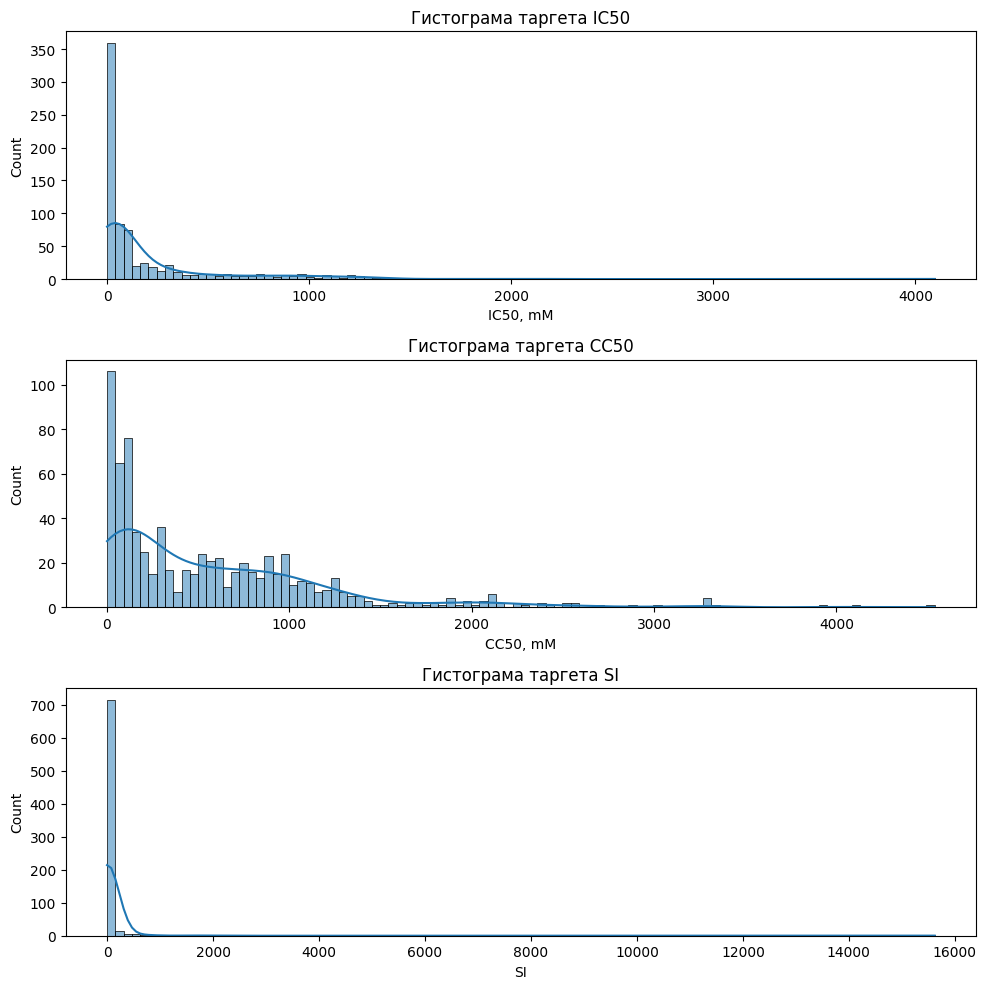

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# IC50
sns.histplot(data=df, x='IC50, mM', bins=100, kde=True, ax=axes[0])
axes[0].set_title('Гистограма таргета IC50')

# CC50
sns.histplot(data=df, x='CC50, mM', bins=100, kde=True, ax=axes[1])
axes[1].set_title('Гистограма таргета CC50')

# SI
sns.histplot(data=df, x='SI', bins=100, kde=True, ax=axes[2])
axes[2].set_title('Гистограма таргета SI')

plt.tight_layout()
plt.show()

Рассмотрим распределение SI, которое отличается наличием особенно длинного правостороннего хвоста, также в различных разрезах:

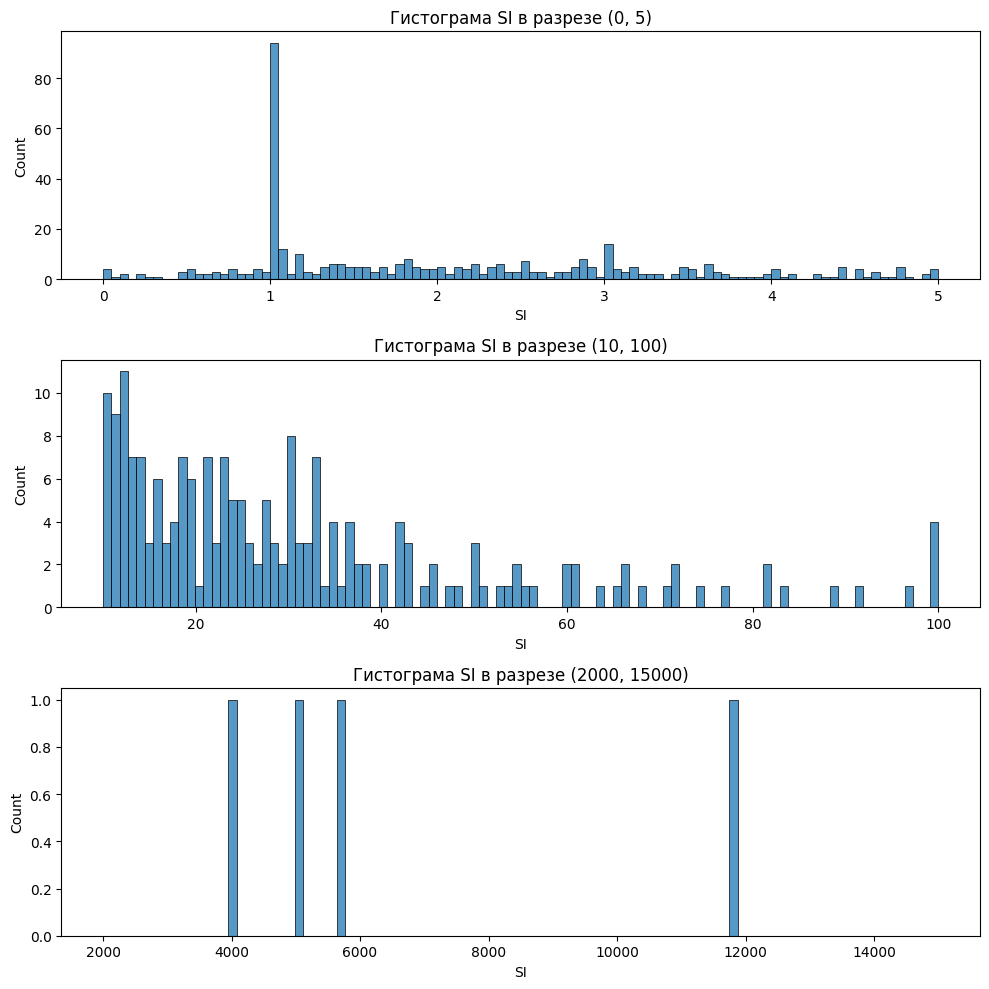

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

sns.histplot(data=df, x='SI', bins=100, binrange=(0,5), ax=axes[0])
axes[0].set_title('Гистограма SI в разрезе (0, 5)')

sns.histplot(data=df, x='SI', bins=100, binrange=(10,100), ax=axes[1])
axes[1].set_title('Гистограма SI в разрезе (10, 100)')

sns.histplot(data=df, x='SI', bins=100, binrange=(2000,15000), ax=axes[2])
axes[2].set_title('Гистограма SI в разрезе (2000, 15000)')

plt.tight_layout()
plt.show()

In [9]:
df[df['SI'] > 3000]

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
91,91,0.032009,128.090060,4001.700000,11.953988,11.953988,0.061346,-0.419485,0.691224,24.818182,312.410,284.186,312.204907,126,0,0.333319,-0.462632,0.462632,0.333319,1.363636,2.000000,2.500000,16.533299,9.878815,2.353217,-2.361863,2.235447,-2.566453,5.886966,-0.138719,2.469305,2.981510,418.368869,16.698306,13.925522,13.925522,10.421453,7.982754,7.982754,5.545865,5.545865,3.804100,3.804100,2.620853,2.620853,-1.40,53534.533748,18.648544,8.901512,5.103401,131.957836,20.524182,0.000000,0.000000,5.90718,0.0,5.969305,4.794537,4.794537,0.0,0.0,13.847474,32.262222,18.538683,24.856656,19.062800,11.876485,0.0,5.316789,5.733667,71.249028,6.606882,11.649125,0,0.0,11.050456,0.0,0.0,0.0,42.774981,19.062800,0.000000,46.957414,11.649125,0.0,0.0,0,90.65,6.103966,9.589074,0.0,30.064133,18.600808,12.841643,6.923737,12.999757,13.847474,5.316789,15.207393,11.099640,0.0,23.365286,2.840980,6.677606,-0.524117,-0.718570,3.477233,7.615276,0.000000,0.750000,22,3,6,1,0,1,0,0,0,5,2,6,7,0,0,0,1,1.2854,84.1561,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
92,92,0.393088,1965.439708,5000.000000,12.006373,12.006373,0.044375,-0.044375,0.571047,37.888889,254.394,226.170,254.211456,104,0,0.361553,-0.457603,0.457603,0.361553,1.277778,1.888889,2.277778,16.546170,9.697377,2.624439,-2.382344,2.657151,-2.437245,5.705250,-0.862420,2.469159,2.029563,355.995327,13.767585,12.746838,12.7

Рассмотрим выбросы в целевых переменных и в каждом графике отметим положение 99-го квантиля. Поскольку у распределений целевых переменных присутствуют довольно большие редкие выбросы, они могут отрицательно сказываться на качестве обучения и предсказаний, поэтому может потребоваться винсоризация целевых переменных.

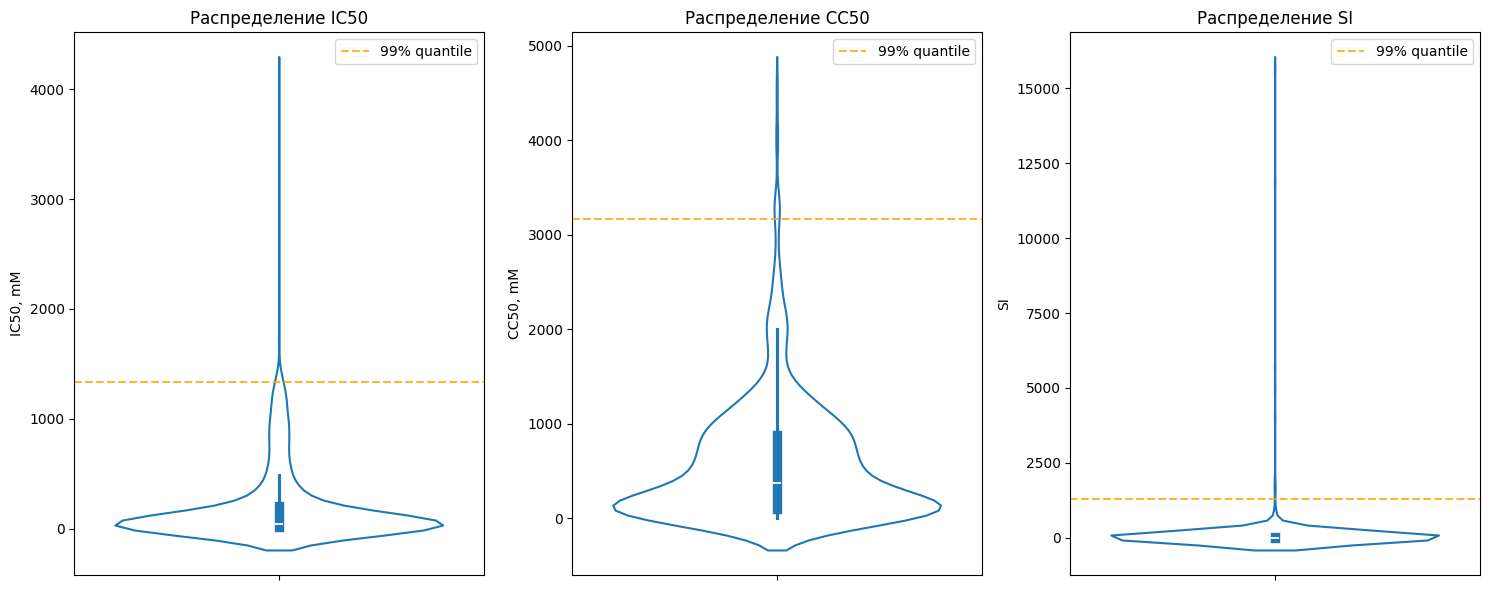

In [10]:
q_ic = df['IC50, mM'].quantile(0.99)
q_cc = df['CC50, mM'].quantile(0.99)
q_si = df['SI'].quantile(0.99)

fix, axes = plt.subplots(1, 3, figsize=(15, 6))

sns.violinplot(data=df, y='IC50, mM', fill=False, ax=axes[0])
axes[0].set_title('Распределение IC50')
axes[0].axhline(y=q_ic, linestyle='--', alpha=0.8, color='orange', label='99% quantile')
axes[0].legend()

sns.violinplot(data=df, y='CC50, mM', fill=False, ax=axes[1])
axes[1].set_title('Распределение CC50')
axes[1].axhline(y=q_cc, linestyle='--', alpha=0.8, color='orange', label='99% quantile')
axes[1].legend()

sns.violinplot(data=df, y='SI', fill=False, ax=axes[2])
axes[2].set_title('Распределение SI')
axes[2].axhline(y=q_si, linestyle='--', alpha=0.8, color='orange', label='99% quantile')
axes[2].legend()

plt.tight_layout()
plt.show()

Вывод:

Распределения всех целевых переменных содержат редкие экстремальные выбросы. 

В случае переменной IC50, которая показывает концентрацию, при которой вещество убивает 50% вируса, мы видим, что большинство представленных веществ в датасете обладают выстродействующим действием на вирус. 

Ту же тенденцию демонстирует график распределения переменной CC50, - большая часть молекул обладает высокой токсичностью для клеток, однако количество токсичных веществ как минимум в три раза меньше количества эффективных. Также мы видим, что распоеделение CC50 демонстрирует более плавный спад частот к правому хвосту, - то есть высокие значения CC50 встречаются чаще, чем высокие значения IC50, что уже является хорошим знаком, демонстрирующим, что в датасете больше эффективных и положительно действующих веществ, что также подтверждается распределением признака SI ($SI = \frac{CC50}{IC50}$), которое демонстрирует большее количество веществ с значением отношения CC50 к IC50 > 1.

Распределения сильно скошенные, поэтому мы считаем целесообразным провести логарифмирование, чтобы приблизить распределения целевых переменных к нормальному и уменьшить хвосты распределений, а также для повышения качества предсказаний попробуем использовать винсоризацию целевых переменных, поскольку выбросы очень редкие и слишком экстремальные.

## Анализ признаков

In [11]:
df.describe()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,749.000000,749.000000,749.000000,749.000000,751.000000,751.000000,751.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,751.000000,7.510000e+02,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,7.510000e+02,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0000

В датасете есть константные признаки, в которых значения для каждого элемента равно 0. Для модели константные признаки бесполезны, поэтому на этапе предобработки данных мы их удалим. 

Определим все такие признаки:

In [12]:
constant_columns = df.columns[df.nunique() == 1]
print(f"Количество константных признаков: {len(constant_columns)}")
print(constant_columns)

Количество константных признаков: 18
Index(['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH',
       'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo',
       'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam',
       'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd',
       'fr_thiocyan'],
      dtype='object')


Проанализируем взаимосвязь между признаками при помощи коэффициента корреляции. Определим признаки, коэффициент корреляции которых превышает 0.98.

In [13]:
corr_matrix = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI']).corr()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
corr_pairs = upper.unstack().dropna()
strong_corr = corr_pairs[abs(corr_pairs) > 0.98]
abs(strong_corr).sort_values(ascending=False)

MaxEStateIndex          MaxAbsEStateIndex         1.000000
fr_benzene              NumAromaticCarbocycles    1.000000
fr_Nhpyrrole            fr_Ar_NH                  1.000000
fr_phenol_noOrthoHbond  fr_phenol                 1.000000
fr_COO2                 fr_COO                    1.000000
fr_nitro_arom_nonortho  fr_nitro_arom             1.000000
ExactMolWt              MolWt                     0.999999
HeavyAtomCount          Chi1                      0.998746
HeavyAtomMolWt          MolWt                     0.996985
ExactMolWt              HeavyAtomMolWt            0.996955
HeavyAtomCount          Chi0                      0.995872
Chi0                    NumValenceElectrons       0.994842
HeavyAtomCount          LabuteASA                 0.994571
LabuteASA               Chi1                      0.993182
Chi0v                   Chi0n                     0.992707
Chi1                    Chi0                      0.990843
HeavyAtomCount          NumValenceElectrons       0.9906

Поскольку в нашем датасете достаточно высокая мультиколлинеарность, - обнаружено 91 пара признаков с коэффициентом корреляции более 0.95, то мы будем использовать алгоритмы, основанные на деревьях, которые менее чувствительные к мультиколлинеарности, чем стандароные линейные модели. Однако даже для boosting моделей большое количество коррелированных фич может пивести к переобучению, поэтому необходимо будет избавиться от сильно коррелирующих признаков.

In [14]:
high_corr_to_drop = ['MaxAbsEStateIndex', 'NumAromaticCarbocycles', 'ExactMolWt', 'HeavyAtomMolWt', 
                     'HeavyAtomCount', 'NumValenceElectrons', 'LabuteASA', 'Chi0', 'Chi0v', 'Chi0n', 'Chi1n',
                    'MolMR']

Рассмотрим признак **Ipc (Information Power Content)** - молекулярный дескриптор, связанный с информационным содержанием структуры молекулы. 

In [15]:
df['Ipc'].describe()

count    7.510000e+02
mean     6.327782e+10
std      1.449887e+12
min      1.071072e+02
25%      2.144640e+04
50%      1.199779e+05
75%      5.720135e+06
max      3.951781e+13
Name: Ipc, dtype: float64

Значения параметра Ipc обычно растут примерно экспоненциально с увеличением значений молекулы и могут достигать огромных размеров, поэтому на этапе FE применим к этому признаку логарифмирование. Продемонстрируем сказанное графиками:

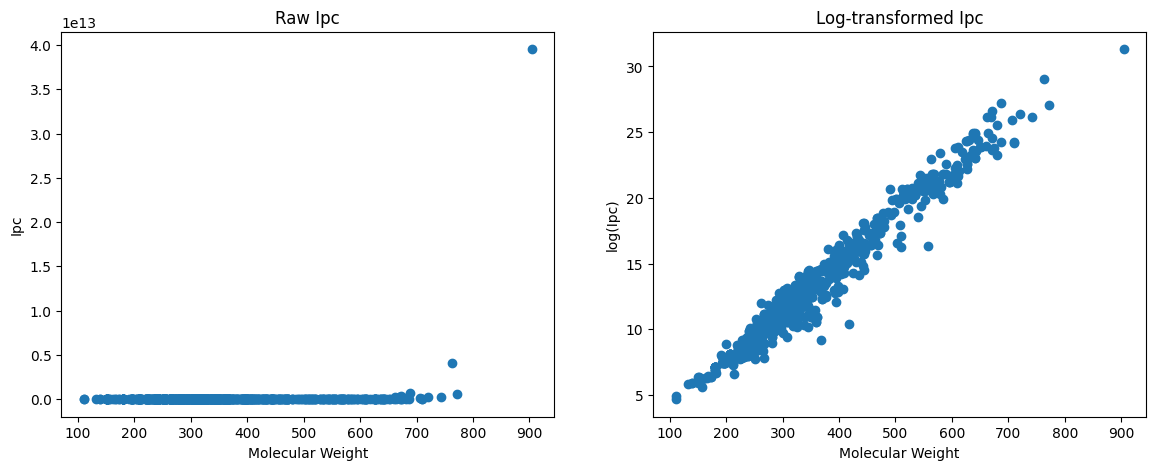

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

ax[0].scatter(df['MolWt'], df['Ipc'])
ax[0].set_title('Raw Ipc')
ax[0].set_xlabel('Molecular Weight')
ax[0].set_ylabel('Ipc')

ax[1].scatter(df['MolWt'], np.log1p(df['Ipc']))
ax[1].set_title('Log-transformed Ipc')
ax[1].set_xlabel('Molecular Weight')
ax[1].set_ylabel('log(Ipc)')

plt.show()

## Пропуски

Исследуем датасет на предмет наличия пропусков в данных

In [17]:
print(f"Общее количество пропущенных значений в датасете: {df.isna().sum().sum()}")
df_nans = df.isna().sum()
print("Пропуски по столбцам:")
display(df_nans[df_nans > 0])

Общее количество пропущенных значений в датасете: 24
Пропуски по столбцам:


MaxPartialCharge       2
MinPartialCharge       2
MaxAbsPartialCharge    2
MinAbsPartialCharge    2
BCUT2D_MWHI            2
BCUT2D_MWLOW           2
BCUT2D_CHGHI           2
BCUT2D_CHGLO           2
BCUT2D_LOGPHI          2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
dtype: int64

Пропусков в датасете немного и подозрительным является тот факт, что количество их в каждом столбце. где присутствуют пропуски, одинаково. Рассмотрим эти строки, скорее всего пропуски находятся всего в двух наблюдениях:

In [18]:
df.loc[df['MaxPartialCharge'].isna(), ['MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 
                                       'MinAbsPartialCharge', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI',
                                       'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW']]

,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW
331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Действительно пропуски находятся только в двух молекулах и пропущены значения в одних и тех же признаках, что может означать какой-то сбой при подготовке данных. Учитывая, что остальные значения молекул заполнены, пропуски всего в двух наблюдениях, а признаки сильно коррелированы, мы можем предсказать эти значения на основе других фич при помощи алгоритма IterativeImputer.

In [19]:
imputer = IterativeImputer(
    max_iter=10,
    random_state=42
)

df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    index=df.index,
    columns=df.columns
)

In [20]:
print(f"Количество пропусков в датасете: {df_imputed.isna().sum().sum()}")

Количество пропусков в датасете: 0


## Вывод по EDA

В результате разведочного анализа данных:
- Была выявлена желательность логарифмирования и винсоризации целевых переменных ввиду сильной скошенности их распределений.
- Обнаружено присутствие в датасете 18 константных признаков, которые было решено удалить на этапе предобработки данных.
- Обнаружена высокая мультиколлинеарность признакового пространства и принято решение избавиться от признаков с коэффициентом корреляции > 0.98, поскольку они не дают модели новой информации.
- Определена необходимость логарифмирования признака Ipc.
- Заполнены пропуски в данных при помощи алгоритма IterativeImputer.

# Feature Engineering

In [21]:
# Разделим датасет на признаки и таргеты
X = df_imputed.drop(columns=['index', 'IC50, mM', 'CC50, mM', 'SI'])
y = df_imputed[['IC50, mM', 'CC50, mM', 'SI']] # multi-output 
# Вынесем также таргеты в отдельные переменные для тестирования раздельных предсказаний:
y_ic = df_imputed['IC50, mM']
y_cc = df_imputed['CC50, mM']
y_si = df_imputed['SI']

In [22]:
# Удалим константные признаки
X = X.drop(columns=constant_columns)

# Напишем функцию добавления производных признаков 
def add_features(X):
    # логарифмирование признака Ipc
    X['Ipc_log'] = np.log1p(X['Ipc'])
    X.drop(columns=['Ipc'], inplace=True)

    """
    Группа признаков SlogP_VSA разбивает поверхность молекулы по гидрофобности. Добавим признаки:
    - общая площадь поверхности, связанная с липофильностью: Total_SlogP_VSA
    - какая доля поверхности является сильно гидрофобной: Hydrophobic_Ratio (гидрофобные молекулы лучше проникают через мембраны)
    """
    slogp_cols = [c for c in X.columns if 'SlogP_VSA' in c]
    X['Total_SlogP_VSA'] = X[slogp_cols].sum(axis=1)
    X['Hydrophobic_Ratio'] = (X['SlogP_VSA10'] + X['SlogP_VSA11'] + X['SlogP_VSA12']) / (X['Total_SlogP_VSA'] + 1e-8)
    
    """
    Группа признаков PEOE_VSA описывает площадь поверхности атомов в определённом диапазоне зарядов. Добавим признак:
    - суммарная площадь поверхности: Total_PEOE_VSA
    """
    peoe_cols = [c for c in X.columns if 'PEOE_VSA' in c]
    X['Total_PEOE_VSA'] = X[peoe_cols].sum(axis=1)

    # То же самое сделаем с группой признаков EState_VSA:
    estate_cols = [c for c in X.columns if 'EState_VSA' in c]
    X['Total_EState_VSA'] = X[estate_cols].sum(axis=1)

    # Насколько молекула гибкая относительно своего размера 
    X['Flexibility_Index'] = X['NumRotatableBonds'] / (X['HeavyAtomCount'] + 1e-8)

    # Насколько молекула неповоротливая 
    X['Rigidity_Index '] = X['RingCount'] / X['HeavyAtomCount']

    # Насколько молекула полярна относительно своего размера:
    X['TPSA_per_atom'] = X['TPSA'] / X['HeavyAtomCount']

    # Плотность полярных функциональных групп относительно размера молекулы
    X['Polar_H_Density'] = (X['NumHDonors'] + X['NumHAcceptors']) / df['MolWt']

    # Насколько молекула гидрофобная для своего размера
    X['LogP_Density'] = X['MolLogP'] / X['MolWt']

    # агрегируем все токсичные fr_ , может помочь модели предсказывать CC50
    toxic_cols = ['fr_nitro', 'fr_aldehyde', 'fr_epoxide', 'fr_hdrzine', 'fr_alkyl_halide', 'fr_allylic_oxid', 'fr_aniline', 'fr_halogen', 'fr_azo']
    X['Toxic_Fragment_Count'] = X[toxic_cols].sum(axis=1)

    # аргегируем функциональные группы, дающие молекуле бОльшую полярность
    polar_cols = ['fr_Al_OH', 'fr_Ar_OH', 'fr_NH1', 'fr_NH2', 'fr_amide', 'fr_ester', 'fr_ether', 'fr_urea', 'fr_COO', 'fr_COO2']
    X['Polar_Group_Count'] = X[polar_cols].sum(axis=1)

    fr_cols = [c for c in X.columns if 'fr_' in c]
    
    X.drop(columns=fr_cols, inplace=True)
    
    return X

# добавим новые признаки
X = add_features(X)

# удалим избыточные признаки с высокой корреляцией 
X = X.drop(columns=high_corr_to_drop)

In [23]:
X.shape

(751, 121)

In [24]:
# Винсоризация целевых переменных 
upper_ic = y['IC50, mM'].quantile(0.99)
upper_cc = y['CC50, mM'].quantile(0.99)
upper_si = y['SI'].quantile(0.99)

y_ic = y_ic.clip(upper=upper_ic)
y_cc = y_cc.clip(upper=upper_cc)
y_si = y_si.clip(upper=upper_si)

# y['IC50, mM'] = y['IC50, mM'].clip(upper=upper_ic)
# y['CC50, mM'] = y['CC50, mM'].clip(upper=upper_cc)
# y['SI'] = y['SI'].clip(upper=upper_si)

# Обучение моделей и подбор гиперпараметров

В распределении целевых переменных наблюдается выраженный дисбаланс: большинство соединений сосредоточено в области типичных значений, тогда как высокоактивные или высокоселективные соединения встречаются значительно реже. Такие редкие области таргета представляют особую сложность для моделей регрессии, поскольку стандартные функции потерь (например, MSE/RMSE) в основном оптимизируются под наиболее частые значения.

Для повышения качества предсказания редких, но биологически наиболее значимых соединений были протестированы следующие подходы:

- Логарифмирование таргетов
- Винсоризация

## Оптимизация гиперпараметров с Optuna для CatBoost

In [25]:
%%time

y_log = np.log1p(y)

def objective_cat(trial):
    cat_params = {
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.03, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 20),
        'iterations': trial.suggest_int('iterations', 300, 2000),

        'loss_function': 'RMSE',
        'verbose': 0,
        'random_state': 42
    }

    model = MultiOutputRegressor(CatBoostRegressor(**cat_params))

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = []

    for train_idx, test_idx in kf.split(X):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y_log.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model.fit(X_train, y_train)

        preds = np.expm1(model.predict(X_test))

        rmse = root_mean_squared_error(y_test, preds)

        scores.append(rmse)

    return np.mean(scores)

study_cat = optuna.create_study(direction='minimize')

study_cat.optimize(objective_cat, n_trials=5)

[I 2026-05-22 17:17:56,062] A new study created in memory with name: no-name-00083b32-9670-4f79-ad0e-8bc9963bb32e
[I 2026-05-22 17:18:31,539] Trial 0 finished with value: 472.2266041502062 and parameters: {'depth': 4, 'learning_rate': 0.020835065205655208, 'l2_leaf_reg': 7.701511964602998, 'iterations': 1918}. Best is trial 0 with value: 472.2266041502062.
[I 2026-05-22 17:18:51,644] Trial 1 finished with value: 484.57593664668104 and parameters: {'depth': 4, 'learning_rate': 0.014343839520384333, 'l2_leaf_reg': 2.9727459560498186, 'iterations': 1075}. Best is trial 0 with value: 472.2266041502062.
[I 2026-05-22 17:20:56,768] Trial 2 finished with value: 472.9118453963483 and parameters: {'depth': 7, 'learning_rate': 0.014174123657581627, 'l2_leaf_reg': 2.3205996487796847, 'iterations': 1915}. Best is trial 0 with value: 472.2266041502062.
[I 2026-05-22 17:22:10,245] Trial 3 finished with value: 499.45171858592937 and parameters: {'depth': 8, 'learning_rate': 0.014486931894452559, 'l2_

CPU times: total: 2h 13min 24s
Wall time: 4min 26s


In [26]:
best_params = study_cat.best_params
best_params.update({
    'loss_function': 'RMSE',
    'verbose': 0,
    'random_state': 42
})

best_cat_model = MultiOutputRegressor(CatBoostRegressor(**best_params))

best_cat_model.fit(X, y_log)

preds_cat = np.expm1(best_cat_model.predict(X))

rmse = root_mean_squared_error(y, preds_cat)
print(rmse)

449.1443335854636


## Feature Importance

In [27]:
feature_importance_ic50 = pd.DataFrame({
    'feature': X.columns,
    'importance': best_cat_model.estimators_[0].feature_importances_
}).sort_values('importance', ascending=False)

feature_importance_cc50 = pd.DataFrame({
    'feature': X.columns,
    'importance': best_cat_model.estimators_[1].feature_importances_
}).sort_values('importance', ascending=False)

feature_importance_si = pd.DataFrame({
    'feature': X.columns,
    'importance': best_cat_model.estimators_[2].feature_importances_
}).sort_values('importance', ascending=False)

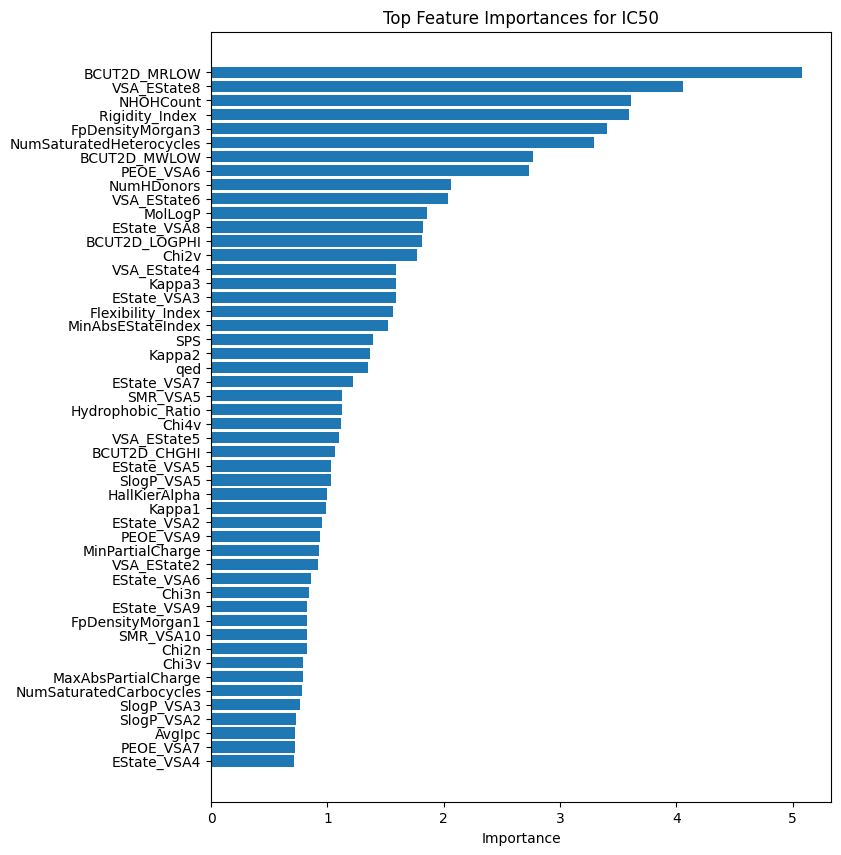

In [28]:
top_f = 50
fi_ic50 = feature_importance_ic50.head(top_f)

plt.figure(figsize=(8, 10))
plt.barh(fi_ic50['feature'], fi_ic50['importance'])
plt.gca().invert_yaxis()

plt.title('Top Feature Importances for IC50')
plt.xlabel('Importance')
plt.show()

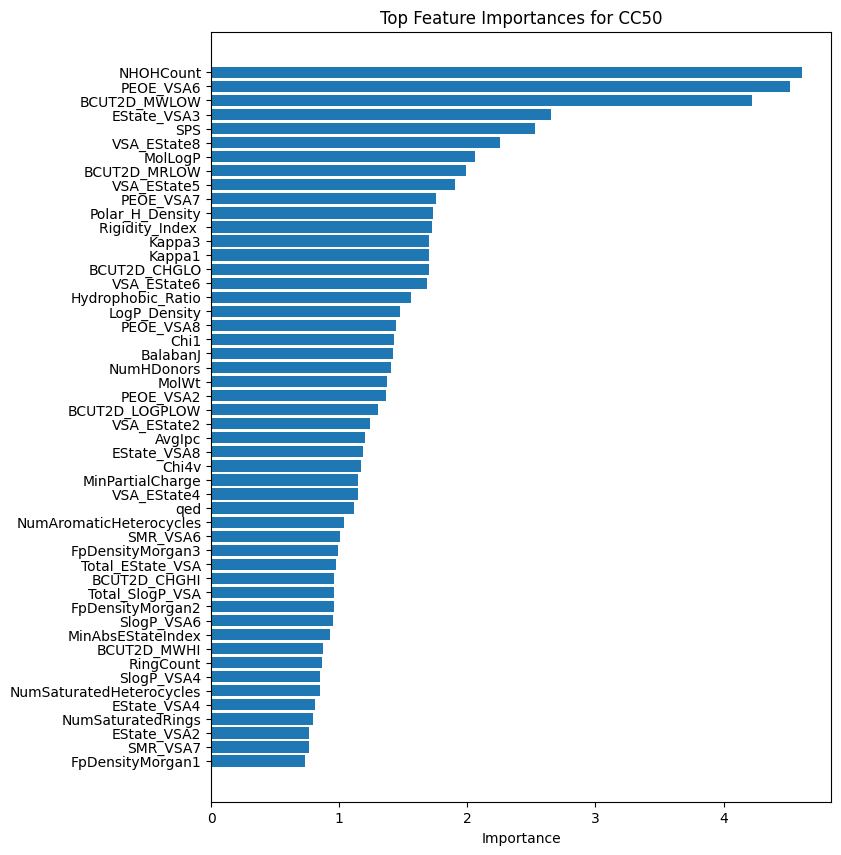

In [29]:
top_f = 50
fi_cc50 = feature_importance_cc50.head(top_f)

plt.figure(figsize=(8, 10))
plt.barh(fi_cc50['feature'], fi_cc50['importance'])
plt.gca().invert_yaxis()

plt.title('Top Feature Importances for CC50')
plt.xlabel('Importance')
plt.show()

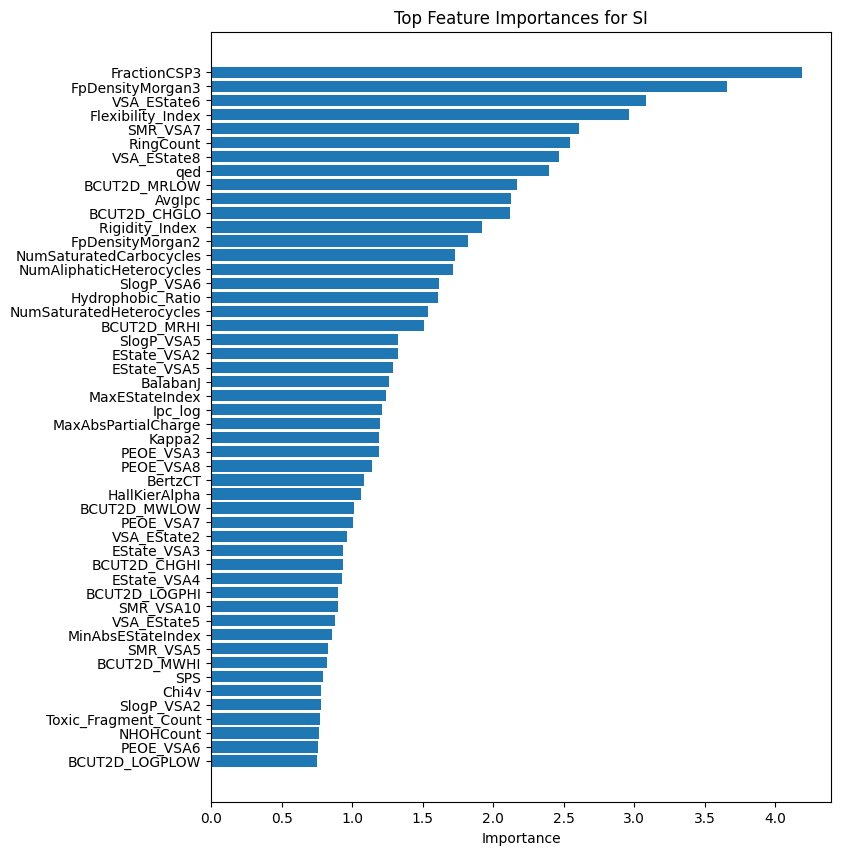

In [30]:
top_f = 50
fi_si = feature_importance_si.head(top_f)

plt.figure(figsize=(8, 10))
plt.barh(fi_si['feature'], fi_si['importance'])
plt.gca().invert_yaxis()

plt.title('Top Feature Importances for SI')
plt.xlabel('Importance')
plt.show()

In [31]:
zero_importance = feature_importance_ic50[feature_importance_ic50['importance'] < 0.2]
zero_importance

,feature,importance
50,SMR_VSA1,0.183655
65,SlogP_VSA4,0.179619
38,PEOE_VSA11,0.177497
42,PEOE_VSA2,0.150242
71,EState_VSA1,0.146439
110,Total_SlogP_VSA,0.143198
40,PEOE_VSA13,0.141302
69,SlogP_VSA8,0.138688
45,PEOE_VSA5,0.131632
107,RingCount,0.114240


In [32]:
zero_importance = feature_importance_cc50[feature_importance_cc50['importance'] < 0.2]
zero_importance

,feature,importance
120,Polar_Group_Count,0.192741
81,EState_VSA9,0.188892
8,MaxAbsPartialCharge,0.168719
50,SMR_VSA1,0.159967
91,VSA_EState9,0.156682
71,EState_VSA1,0.127495
99,NumAromaticRings,0.117895
69,SlogP_VSA8,0.107934
102,NumHeteroatoms,0.099471
68,SlogP_VSA7,0.090407


In [33]:
zero_importance = feature_importance_si[feature_importance_si['importance'] < 0.2]
zero_importance

,feature,importance
37,PEOE_VSA10,0.194941
102,NumHeteroatoms,0.171052
94,NOCount,0.163388
120,Polar_Group_Count,0.158557
72,EState_VSA10,0.142325
68,SlogP_VSA7,0.119566
39,PEOE_VSA12,0.118984
45,PEOE_VSA5,0.108839
98,NumAromaticHeterocycles,0.091116
44,PEOE_VSA4,0.068796


## Анализ ошибок 

In [34]:
#preds = preds_cat 

#error_ic = abs(y['IC50, mM'] - preds[:, 0])
#error_cc = abs(y['CC50, mM'] - preds[:, 1])
#error_si = abs(y['SI'] - preds[:, 2])

#fig, axes = plt.subplots(3, 1, figsize=(10, 8))

#axes[0].scatter(y['IC50, mM'], error_ic, alpha=0.5)
#axes[0].set_title("IC50: error VS target")
#axes[0].set_xlabel("target")
#axes[0].set_ylabel("absolute error")

#axes[1].scatter(y['CC50, mM'], error_cc, alpha=0.5)
#axes[1].set_title("CC50: error VS target")
#axes[1].set_xlabel("target")
#axes[1].set_ylabel("absolute error")

#axes[2].scatter(y['SI'], error_si, alpha=0.5)
#axes[2].set_title("SI: error VS target")
#axes[2].set_xlabel("target")
#axes[2].set_ylabel("absolute error")

#plt.tight_layout()
#plt.show()

## Оптимизация Optuna | LightGBM | IC50

In [35]:
%%time

y_ic_log = np.log1p(y_ic)

def objective_lgbm_ic(trial):
    max_depth = trial.suggest_int('max_depth', 4, 8)

    lgbm_params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth': max_depth,
        'num_leaves': trial.suggest_int('num_leaves', 16, 2 ** max_depth),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        
        'objective': 'huber',
        'alpha': 0.5,
        'metric': 'rmse',
        'random_state': 42,
        'verbosity': -1
    }

    model = LGBMRegressor(**lgbm_params)

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores_ic = []

    for train_idx, test_idx in kf.split(X):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train_ic = y_ic_log.iloc[train_idx]
        y_test_ic = y_ic.iloc[test_idx]

        model.fit(X_train, y_train_ic)
        ic_preds = np.expm1(model.predict(X_test))

        rmse_ic = root_mean_squared_error(y_test_ic, ic_preds)
        scores_ic.append(rmse_ic)

    return np.mean(scores_ic)

study_lgbm_ic = optuna.create_study(direction='minimize')

study_lgbm_ic.optimize(objective_lgbm_ic, n_trials=30)

[I 2026-05-22 17:22:30,503] A new study created in memory with name: no-name-be84c972-b875-42fb-9d8a-7c7c0e7f9e47
[I 2026-05-22 17:22:34,675] Trial 0 finished with value: 299.23483736637434 and parameters: {'max_depth': 5, 'n_estimators': 1879, 'learning_rate': 0.026434433177227802, 'num_leaves': 18, 'min_child_samples': 48, 'lambda_l2': 3.1445280849270063e-05}. Best is trial 0 with value: 299.23483736637434.
[I 2026-05-22 17:22:35,353] Trial 1 finished with value: 345.3623454327882 and parameters: {'max_depth': 7, 'n_estimators': 446, 'learning_rate': 0.0021411492477821825, 'num_leaves': 33, 'min_child_samples': 50, 'lambda_l2': 0.011925907048623027}. Best is trial 0 with value: 299.23483736637434.
[I 2026-05-22 17:22:37,177] Trial 2 finished with value: 293.94833030511137 and parameters: {'max_depth': 5, 'n_estimators': 1116, 'learning_rate': 0.0438986657789847, 'num_leaves': 23, 'min_child_samples': 35, 'lambda_l2': 6.985504004250312}. Best is trial 2 with value: 293.94833030511137.

CPU times: total: 16min 47s
Wall time: 1min 5s


In [36]:
ic_best_params = study_lgbm_ic.best_params
ic_best_params.update({
    'objective': 'regression',
    'random_state': 42,
    'verbosity': -1
})

ic_best_lgbm_model =  LGBMRegressor(**ic_best_params)

## Оптимизация Optuna | LightGBM | CC50

In [37]:
%%time

y_cc_log = np.log1p(y_cc)

def objective_lgbm_cc(trial):
    max_depth = trial.suggest_int('max_depth', 4, 8)

    lgbm_params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth': max_depth,
        'num_leaves': trial.suggest_int('num_leaves', 16, 2 ** max_depth),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        
        'objective': 'huber',
        'alpha': 0.5,
        'metric': 'rmse',
        'random_state': 42,
        'verbosity': -1
    }

    model = LGBMRegressor(**lgbm_params)

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores_cc = []

    for train_idx, test_idx in kf.split(X):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train_cc = y_cc_log.iloc[train_idx]
        y_test_cc = y_cc.iloc[test_idx]

        model.fit(X_train, y_train_cc)
        cc_preds = np.expm1(model.predict(X_test))

        rmse_cc = root_mean_squared_error(y_test_cc, cc_preds)
        scores_cc.append(rmse_cc)

    return np.mean(scores_cc)

study_lgbm_cc = optuna.create_study(direction='minimize')

study_lgbm_cc.optimize(objective_lgbm_cc, n_trials=30)

[I 2026-05-22 17:23:36,030] A new study created in memory with name: no-name-e46017f1-34cb-4725-b558-26b9dfd4441e
[I 2026-05-22 17:23:36,277] Trial 0 finished with value: 687.5825102219502 and parameters: {'max_depth': 8, 'n_estimators': 116, 'learning_rate': 0.0014814602731970275, 'num_leaves': 29, 'min_child_samples': 42, 'lambda_l2': 0.001159106180639623}. Best is trial 0 with value: 687.5825102219502.
[I 2026-05-22 17:23:37,274] Trial 1 finished with value: 673.3102574761372 and parameters: {'max_depth': 7, 'n_estimators': 290, 'learning_rate': 0.001694648891169999, 'num_leaves': 46, 'min_child_samples': 14, 'lambda_l2': 1.1345302054685938e-05}. Best is trial 1 with value: 673.3102574761372.
[I 2026-05-22 17:23:37,712] Trial 2 finished with value: 671.6015850619857 and parameters: {'max_depth': 6, 'n_estimators': 158, 'learning_rate': 0.003604399927059998, 'num_leaves': 42, 'min_child_samples': 18, 'lambda_l2': 3.2521565552388358e-06}. Best is trial 2 with value: 671.6015850619857.

CPU times: total: 10min 42s
Wall time: 40.6 s


In [38]:
cc_best_params = study_lgbm_cc.best_params
cc_best_params.update({
    'objective': 'regression',
    'random_state': 42,
    'verbosity': -1
})

cc_best_lgbm_model =  LGBMRegressor(**cc_best_params)

## Оптимизация Optuna | LightGBM | SI

In [39]:
%%time

y_si_log = np.log1p(y_si)

def objective_lgbm_si(trial):
    max_depth = trial.suggest_int('max_depth', 4, 8)

    lgbm_params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth': max_depth,
        'num_leaves': trial.suggest_int('num_leaves', 16, 2 ** max_depth),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        
        'objective': 'huber',
        'alpha': 0.5,
        'metric': 'rmse',
        'random_state': 42,
        'verbosity': -1
    }

    model = LGBMRegressor(**lgbm_params)
    model_ic = LGBMRegressor(**ic_best_params)
    model_cc = LGBMRegressor(**cc_best_params)

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores_si = []

    oof_ic = np.zeros(len(X))
    oof_cc = np.zeros(len(X))

    for train_idx, test_idx in kf.split(X):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        # IC50
        y_train_ic = y_ic_log.iloc[train_idx]
        model_ic.fit(X_train, y_train_ic)
        ic_preds = np.expm1(model_ic.predict(X_test))
        oof_ic[test_idx] = ic_preds

        # CC50
        y_train_cc = y_cc_log.iloc[train_idx]
        model_cc.fit(X_train, y_train_cc)
        cc_preds = np.expm1(model_cc.predict(X_test))
        oof_cc[test_idx] = cc_preds

    X_si = X.copy()
    X_si['log_ratio'] = np.log1p(oof_cc) - np.log1p(oof_ic)

    for train_idx, test_idx in kf.split(X):
        X_train = X_si.iloc[train_idx]
        X_test = X_si.iloc[test_idx]

        y_train = y_si_log.iloc[train_idx]
        y_test = y_si.iloc[test_idx]

        model.fit(X_train, y_train)
        si_preds = np.expm1(model.predict(X_test))

        rmse_si = root_mean_squared_error(y_test, si_preds)
        scores_si.append(rmse_si)
    
    return np.mean(scores_si)

study_lgbm_si = optuna.create_study(direction='minimize')

study_lgbm_si.optimize(objective_lgbm_si, n_trials=30)

[I 2026-05-22 17:24:16,612] A new study created in memory with name: no-name-100481e9-39ce-4ff6-8d9e-7920e3cf3c6d
[I 2026-05-22 17:24:20,587] Trial 0 finished with value: 149.71982377829264 and parameters: {'max_depth': 6, 'n_estimators': 173, 'learning_rate': 0.009371392796068143, 'num_leaves': 26, 'min_child_samples': 30, 'lambda_l2': 2.0175363754672915e-08}. Best is trial 0 with value: 149.71982377829264.
[I 2026-05-22 17:24:24,992] Trial 1 finished with value: 149.70464739878568 and parameters: {'max_depth': 5, 'n_estimators': 416, 'learning_rate': 0.003368631074156343, 'num_leaves': 17, 'min_child_samples': 13, 'lambda_l2': 1.470330344239648e-07}. Best is trial 1 with value: 149.70464739878568.
[I 2026-05-22 17:24:29,292] Trial 2 finished with value: 149.41726719285523 and parameters: {'max_depth': 6, 'n_estimators': 347, 'learning_rate': 0.006625425427151552, 'num_leaves': 34, 'min_child_samples': 23, 'lambda_l2': 0.5599005395694007}. Best is trial 2 with value: 149.4172671928552

CPU times: total: 37min 19s
Wall time: 2min 21s


In [40]:
si_best_params = study_lgbm_si.best_params
si_best_params.update({
    'objective': 'regression',
    'random_state': 42,
    'verbosity': -1
})

si_best_lgbm_model =  LGBMRegressor(**si_best_params)

## Optuna | CatBoost | IC50

In [42]:
%%time

y_ic_log = np.log1p(y_ic)

def objective_cat_ic(trial):

    cat_params = {
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.03, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 20),
        'iterations': trial.suggest_int('iterations', 300, 2000),

        'loss_function': 'RMSE',
        'verbose': 0,
        'random_state': 42
    }

    model = CatBoostRegressor(**cat_params)

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores_ic = []

    for train_idx, test_idx in kf.split(X):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train_ic = y_ic_log.iloc[train_idx]
        y_test_ic = y_ic.iloc[test_idx]

        model.fit(X_train, y_train_ic)
        ic_preds = np.expm1(model.predict(X_test))

        rmse_ic = root_mean_squared_error(y_test_ic, ic_preds)
        scores_ic.append(rmse_ic)

    return np.mean(scores_ic)

study_cat_ic = optuna.create_study(direction='minimize')

study_cat_ic.optimize(objective_cat_ic, n_trials=5)

[I 2026-05-22 17:37:56,121] A new study created in memory with name: no-name-1373b223-a5e2-4584-b1e2-2a1c2bbbb957
[I 2026-05-22 17:38:09,916] Trial 0 finished with value: 295.31667211685226 and parameters: {'depth': 5, 'learning_rate': 0.026240406923936577, 'l2_leaf_reg': 19.505680846907456, 'iterations': 1576}. Best is trial 0 with value: 295.31667211685226.
[I 2026-05-22 17:38:26,054] Trial 1 finished with value: 306.9862797388791 and parameters: {'depth': 7, 'learning_rate': 0.010204632898561126, 'l2_leaf_reg': 7.885748500474002, 'iterations': 740}. Best is trial 0 with value: 295.31667211685226.
[I 2026-05-22 17:38:47,213] Trial 2 finished with value: 300.88602980948656 and parameters: {'depth': 6, 'learning_rate': 0.010226587978902484, 'l2_leaf_reg': 16.39688792891623, 'iterations': 1619}. Best is trial 0 with value: 295.31667211685226.
[I 2026-05-22 17:38:50,706] Trial 3 finished with value: 313.699223754635 and parameters: {'depth': 5, 'learning_rate': 0.015224499015526324, 'l2_

CPU times: total: 49min 9s
Wall time: 1min 38s


In [43]:
ic_cat_best_params = study_cat_ic.best_params
ic_cat_best_params.update({
    'loss_function': 'RMSE',
    'verbose': 0,
    'random_state': 42
})
best_cat_ic__model = CatBoostRegressor(**ic_cat_best_params)

## Optuna | CatBoost | CC50

In [45]:
%%time

y_cc_log = np.log1p(y_cc)

def objective_cat_cc(trial):

    cat_params = {
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.03, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 20),
        'iterations': trial.suggest_int('iterations', 300, 2000),

        'loss_function': 'RMSE',
        'verbose': 0,
        'random_state': 42
    }

    model = CatBoostRegressor(**cat_params)

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores_cc = []

    for train_idx, test_idx in kf.split(X):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train_cc = y_cc_log.iloc[train_idx]
        y_test_cc = y_cc.iloc[test_idx]

        model.fit(X_train, y_train_cc)
        cc_preds = np.expm1(model.predict(X_test))

        rmse_cc = root_mean_squared_error(y_test_cc, cc_preds)
        scores_cc.append(rmse_cc)

    return np.mean(scores_cc)

study_cat_cc = optuna.create_study(direction='minimize')

study_cat_cc.optimize(objective_cat_cc, n_trials=5)

[I 2026-05-22 17:42:19,618] A new study created in memory with name: no-name-5dcb91ac-1069-456a-b4b7-16c9c3bebd72
[I 2026-05-22 17:42:44,875] Trial 0 finished with value: 482.16527322299606 and parameters: {'depth': 6, 'learning_rate': 0.010881619590466109, 'l2_leaf_reg': 15.256584829656038, 'iterations': 1929}. Best is trial 0 with value: 482.16527322299606.
[I 2026-05-22 17:43:16,047] Trial 1 finished with value: 479.229517265164 and parameters: {'depth': 8, 'learning_rate': 0.01737662705877385, 'l2_leaf_reg': 4.4518109207479615, 'iterations': 616}. Best is trial 1 with value: 479.229517265164.
[I 2026-05-22 17:44:38,641] Trial 2 finished with value: 465.60026514798955 and parameters: {'depth': 8, 'learning_rate': 0.020050782538936756, 'l2_leaf_reg': 6.588834462267724, 'iterations': 1696}. Best is trial 2 with value: 465.60026514798955.
[I 2026-05-22 17:44:57,687] Trial 3 finished with value: 473.36906515018853 and parameters: {'depth': 7, 'learning_rate': 0.029026002123725792, 'l2_l

CPU times: total: 1h 24min 34s
Wall time: 2min 49s


In [46]:
cc_cat_best_params = study_cat_cc.best_params
cc_cat_best_params.update({
    'loss_function': 'RMSE',
    'verbose': 0,
    'random_state': 42
})
best_cat_cc__model = CatBoostRegressor(**cc_cat_best_params)

## Optuna | CatBoost | SI

In [47]:
%%time

y_si_log = np.log1p(y_si)

def objective_lgbm_si(trial):
    
    cat_params = {
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.03, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 20),
        'iterations': trial.suggest_int('iterations', 300, 2000),

        'loss_function': 'RMSE',
        'verbose': 0,
        'random_state': 42
    }

    model = CatBoostRegressor(**cat_params)
    model_ic = CatBoostRegressor(**ic_cat_best_params)
    model_cc = CatBoostRegressor(**cc_cat_best_params)

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores_si = []

    oof_ic = np.zeros(len(X))
    oof_cc = np.zeros(len(X))

    for train_idx, test_idx in kf.split(X):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        # IC50
        y_train_ic = y_ic_log.iloc[train_idx]
        model_ic.fit(X_train, y_train_ic)
        ic_preds = np.expm1(model_ic.predict(X_test))
        oof_ic[test_idx] = ic_preds

        # CC50
        y_train_cc = y_cc_log.iloc[train_idx]
        model_cc.fit(X_train, y_train_cc)
        cc_preds = np.expm1(model_cc.predict(X_test))
        oof_cc[test_idx] = cc_preds

    X_si = X.copy()
    X_si['log_ratio'] = np.log1p(oof_cc) - np.log1p(oof_ic)

    for train_idx, test_idx in kf.split(X):
        X_train = X_si.iloc[train_idx]
        X_test = X_si.iloc[test_idx]

        y_train = y_si_log.iloc[train_idx]
        y_test = y_si.iloc[test_idx]

        model.fit(X_train, y_train)
        si_preds = np.expm1(model.predict(X_test))

        rmse_si = root_mean_squared_error(y_test, si_preds)
        scores_si.append(rmse_si)
    
    return np.mean(scores_si)

study_lgbm_si = optuna.create_study(direction='minimize')

study_lgbm_si.optimize(objective_lgbm_si, n_trials=5)

[I 2026-05-22 17:46:33,224] A new study created in memory with name: no-name-4a30fc3e-4148-4f1c-9a28-4f726f0ce037
[I 2026-05-22 17:48:23,575] Trial 0 finished with value: 137.38609162938332 and parameters: {'depth': 5, 'learning_rate': 0.014762448260044405, 'l2_leaf_reg': 9.435303667147041, 'iterations': 1714}. Best is trial 0 with value: 137.38609162938332.
[I 2026-05-22 17:50:40,374] Trial 1 finished with value: 139.09776040577282 and parameters: {'depth': 8, 'learning_rate': 0.014079456877148585, 'l2_leaf_reg': 13.3557350772523, 'iterations': 889}. Best is trial 0 with value: 137.38609162938332.
[I 2026-05-22 17:52:25,160] Trial 2 finished with value: 139.56147517220205 and parameters: {'depth': 6, 'learning_rate': 0.014859851837047907, 'l2_leaf_reg': 5.620268202896101, 'iterations': 683}. Best is trial 0 with value: 137.38609162938332.
[I 2026-05-22 17:54:19,074] Trial 3 finished with value: 140.34513012985846 and parameters: {'depth': 8, 'learning_rate': 0.026120716452273783, 'l2_

CPU times: total: 4h 47min 50s
Wall time: 9min 29s


In [48]:
# ✅ Исправленный код
si_cat_best_params = study_lgbm_si.best_params  # <-- исправлено имя переменной
si_cat_best_params.update({
    'loss_function': 'RMSE',
    'verbose': 0,
    'random_state': 42
})
best_cat_si_model = CatBoostRegressor(**si_cat_best_params) # <-- также убрал лишний символ "_"

# Предсказание на тесте

In [49]:
df_test = pd.read_csv('test.csv')
df_test.head()

,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,13.761882,13.761882,0.121946,-0.962625,0.770057,30.580645,450.541,432.397,450.070799,156,0,0.307795,-0.480983,0.480983,0.307795,1.129032,1.967742,2.741935,32.166547,9.704289,2.608086,-2.425359,2.544663,-2.545620,8.056645,-0.147725,3.494848,1.531269,1171.998965,21.275292,16.250243,17.883236,15.058551,10.093357,11.852663,8.159777,10.171294,6.660754,8.495535,5.422732,7.148420,-2.84,2.734932e+07,18.891356,6.831720,2.610159,186.392155,10.006437,6.165776,0.000000,5.907180,5.907180,5.969305,19.283521,0.000000,0.000000,23.098671,30.351141,33.892353,16.712959,29.631406,19.490139,46.569722,0.0,4.89991,23.671624,12.710532,4.899910,74.684093,0,0.000000,4.899910,5.687386,0.000000,23.098671,33.955877,16.133831,23.671624,15.235136,64.243494,0.0,0.000000,0,77.92,23.970893,19.490139,0.0,23.650172,17.795594,9.782284,11.761885,39.335707,41.139256,0.000000,0.000000,0.000000,3.080138,45.049341,13.952413,1.061592,-3.488287,11.053051,3.404616,0.387137,0.0,0.260870,31,1,6,1,3,4,1,1,2,5,1,8,3,0,1,1,6,3.78420,118.3183,1,0,0,0,0,0,0,0,1,1,3,2,0,0,0,2,0,0,0,0,0,0,0,0,0,0,2,2,0,1,0,0,0,0,1,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,170,0,0.238633,-0.507966,0.507966,0.238633,0.906250,1.593750,2.250000,16.707906,9.991346,2.450224,-2.390353,2.369524,-2.597794,5.878314,-0.277225,2.752143,1.885708,1185.055548,23.153972,16.321448,16.321448,15.205616,9.502898,9.502898,7.289468

In [50]:
X_test = df_test.drop(columns=['index'])

In [51]:
# FE если надо..
X_test = df_test.drop(columns=constant_columns)
X_test = add_features(X_test)
X_test = X_test.drop(columns=high_corr_to_drop)

In [54]:
# 1. Убираем index, если он есть в тесте
if 'index' in df_test.columns:
    df_test = df_test.drop(columns=['index'])

# 2. Применяем те же шаги, что и при обучении
X_test = df_test.copy()
X_test = X_test.drop(columns=constant_columns)
X_test = add_features(X_test)
X_test = X_test.drop(columns=high_corr_to_drop)

# 3. 🔑 КРИТИЧНО: Выравниваем порядок столбцов точно как в X
X_test = X_test[X.columns]

# Проверяем, что размерности совпали
print(f"X.shape: {X.shape}, X_test.shape: {X_test.shape}")

# Теперь предсказание сработает без ошибок
final_preds_ic = np.clip(np.expm1(ic_best_lgbm_model.predict(X_test)), 0, None)
final_preds_cc = np.clip(np.expm1(cc_best_lgbm_model.predict(X_test)), 0, None)

X.shape: (751, 121), X_test.shape: (250, 121)


NotFittedError: Estimator not fitted, call fit before exploiting the model.

In [53]:
print(X.shape, X_test.shape)

(751, 121) (250, 121)


In [55]:
# IC50
#ic_best_lgbm_model.fit(X, y_ic_log)
#final_preds_ic = np.clip(np.expm1(ic_best_lgbm_model.predict(X_test)), 0, None)

# CC50
#cc_best_lgbm_model.fit(X, y_cc_log)
#final_preds_cc = np.clip(np.expm1(cc_best_lgbm_model.predict(X_test)), 0, None)

# SI
# oof IC50 & CC50
#oof_ic = np.zeros(len(X))
#oof_cc = np.zeros(len(X))

#kf = KFold(
#        n_splits=5,
#        shuffle=True,
#        random_state=42
#    )

#for train_idx, test_idx in kf.split(X):

#    X_train = X.iloc[train_idx]
#    X_val = X.iloc[test_idx]

#    # IC50
#    y_train_ic = y_ic_log.iloc[train_idx]
#    ic_best_lgbm_model.fit(X_train, y_train_ic)
#    ic_preds = np.clip(np.expm1(ic_best_lgbm_model.predict(X_val)), 0, None)
#    oof_ic[test_idx] = ic_preds

    # CC50
#    y_train_cc = y_cc_log.iloc[train_idx]
#    cc_best_lgbm_model.fit(X_train, y_train_cc)
#    cc_preds = np.clip(np.expm1(cc_best_lgbm_model.predict(X_val)), 0, None)
#    oof_cc[test_idx] = cc_preds

# Train for SI
#X_train_si = X.copy()
#X_train_si['SI_ratio_log'] = np.log1p(oof_cc) - np.log1p(oof_ic)

#si_best_lgbm_model.fit(X_train_si, y_si_log)

# Prediction for SI
#X_test_si = X_test.copy()
#X_test_si['SI_ratio_log'] = np.log1p(final_preds_cc) - np.log1p(final_preds_ic)

#final_preds_si = np.clip(np.expm1(si_best_lgbm_model.predict(X_test_si)), 0, None)

In [56]:
# 🔹 1. Предсказания LightGBM
ic_best_lgbm_model.fit(X, y_ic_log)
cc_best_lgbm_model.fit(X, y_cc_log)
final_preds_ic_lgbm = np.clip(np.expm1(ic_best_lgbm_model.predict(X_test)), 0, None)
final_preds_cc_lgbm = np.clip(np.expm1(cc_best_lgbm_model.predict(X_test)), 0, None)

# 🔹 2. Предсказания CatBoost
# ⚠️ Обратите внимание: в вашем ноутбуке модели CatBoost созданы с двойным подчёркиванием
best_cat_ic__model.fit(X, y_ic_log)
best_cat_cc__model.fit(X, y_cc_log)
final_preds_ic_cat = np.clip(np.expm1(best_cat_ic__model.predict(X_test)), 0, None)
final_preds_cc_cat = np.clip(np.expm1(best_cat_cc__model.predict(X_test)), 0, None)

# 🔹 3. Блендинг IC50 и CC50
w = 0.5  # Вес для каждой модели (можно менять, например 0.6/0.4)
final_preds_ic = w * final_preds_ic_lgbm + w * final_preds_ic_cat
final_preds_cc = w * final_preds_cc_lgbm + w * final_preds_cc_cat

# 🔹 4. Предсказания и блендинг SI
X_test_si = X_test.copy()
X_test_si['SI_ratio_log'] = np.log1p(final_preds_cc) - np.log1p(final_preds_ic)

# SI LightGBM
si_best_lgbm_model.fit(X_train_si, y_si_log)
final_preds_si_lgbm = np.clip(np.expm1(si_best_lgbm_model.predict(X_test_si)), 0, None)

# SI CatBoost
best_cat_si_model.fit(X_train_si, y_si_log)
final_preds_si_cat = np.clip(np.expm1(best_cat_si_model.predict(X_test_si)), 0, None)

# Финальный блендинг SI
final_preds_si = w * final_preds_si_lgbm + w * final_preds_si_cat

print("✅ Блендинг завершён. Предикты готовы для submission.")

NameError: name 'X_train_si' is not defined

In [ ]:
# (Предполагается, что у вас уже есть final_preds_ic_lgbm, final_preds_cc_lgbm, final_preds_si_lgbm)
# Добавьте генерацию предиктов CatBoost для теста, если ещё нет:
# final_preds_ic_cat = np.clip(np.expm1(ic_best_cat_model.predict(X_test)), 0, None)
# final_preds_cc_cat = np.clip(np.expm1(cc_best_cat_model.predict(X_test)), 0, None)
# final_preds_si_cat = np.clip(np.expm1(si_best_cat_model.predict(X_test_si)), 0, None)

# 🔽 ВСТАВИТЬ ЭТОТ БЛОК:
w_lgbm = 0.5
w_cat = 0.5

final_preds_ic = w_lgbm * final_preds_ic_lgbm + w_cat * final_preds_ic_cat
final_preds_cc = w_lgbm * final_preds_cc_lgbm + w_cat * final_preds_cc_cat
final_preds_si = w_lgbm * final_preds_si_lgbm + w_cat * final_preds_si_cat

In [ ]:
# 🔽 ВСТАВИТЬ СРАЗУ ПОСЛЕ РАСЧЁТА final_preds_si:
w_model = 0.7
w_formula = 0.3

final_preds_si = (w_model * final_preds_si) + \
                 (w_formula * (final_preds_cc / final_preds_ic))

In [ ]:
submission_df = pd.DataFrame({
    "IC50": final_preds_ic,
    "CC50": final_preds_cc,
    "SI": final_preds_si
}).reset_index()
submission_df.head()

In [ ]:
submission_df.to_csv('submission_lgbm_ratio_nofe.csv', index=False)

In [ ]:
# Анализ ошибок
preds = preds_cat 

error_ic = abs(y['IC50, mM'] - preds[:, 0])
error_cc = abs(y['CC50, mM'] - preds[:, 1])
error_si = abs(y['SI'] - preds[:, 2])

fig, axes = plt.subplots(3, 1, figsize=(10, 8))

axes[0].scatter(y['IC50, mM'], error_ic, alpha=0.5)
axes[0].set_title("IC50: error VS target")
axes[0].set_xlabel("target")
axes[0].set_ylabel("absolute error")

axes[1].scatter(y['CC50, mM'], error_cc, alpha=0.5)
axes[1].set_title("CC50: error VS target")
axes[1].set_xlabel("target")
axes[1].set_ylabel("absolute error")

axes[2].scatter(y['SI'], error_si, alpha=0.5)
axes[2].set_title("SI: error VS target")
axes[2].set_xlabel("target")
axes[2].set_ylabel("absolute error")

plt.tight_layout()
plt.show()